# Young Driver Collision Severity Analysis

## STATS19 data, England and Wales, 2018–2024

This notebook contains the Python analysis supporting the EMA project.

### Research question

To what extent are specific driving conditions and collision characteristics associated with higher-severity road traffic collisions involving 17–19-year-old car drivers in England and Wales between 2018 and 2024, and how do combinations of these factors relate to collision severity?

### Study population

- Car drivers aged 17–19
- England and Wales
- Police-reported injury collisions
- 2018–2024

### Characteristics examined

- Night-time conditions
- Weekend status
- Young-passenger presence
- Driver sex
- Vehicle age

### Outcome

Collision severity is harmonised into:

- Higher severity
- Lower severity

The analysis examines associations rather than causal relationships.

# 1. Imports and configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
# Study parameters

START_YEAR = 2018
END_YEAR = 2024

MIN_DRIVER_AGE = 17
MAX_DRIVER_AGE = 19

MIN_YOUNG_PASSENGER_AGE = 15
MAX_YOUNG_PASSENGER_AGE = 21

RANDOM_STATE = 42

# 2. Data acquisition

The analysis uses the Department for Transport STATS19 collision, vehicle and casualty datasets for 2018–2024. The three datasets are linked using the collision identifier. The collision data provide collision-level circumstances and severity, the vehicle data identify the characteristics of the young driver and vehicle, and the casualty data are used to identify the presence of young passengers.

## Analysis workflow

The analysis follows a staged workflow:

1. Load and inspect the STATS19 collision, vehicle and casualty datasets.
2. Restrict the collision data to England and Wales and the study period.
3. Identify qualifying car drivers aged 17–19.
4. Harmonise collision severity into higher- and lower-severity outcomes.
5. Derive the night-time, weekend and young-passenger indicators.
6. Construct separate collision-level and driver–vehicle-level analysis datasets.
7. Examine individual characteristics using descriptive statistics and chi-square tests.
8. Estimate adjusted associations using logistic regression.
9. Evaluate whether the selected characteristics provide useful predictive discrimination using logistic regression, a decision tree and random forest models.
10. Examine naturally occurring combinations of characteristics using a descriptive profile analysis.

The collision-level dataset is used where each collision must contribute one observation. Vehicle age is retained at driver–vehicle level because some collisions contain more than one qualifying young driver and therefore cannot always be assigned a unique vehicle age.

In [3]:
# Load the CSV directly from the internet
url_vehicles = "https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-vehicle-1979-latest-published-year.csv"
url_collisions = "https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-collision-1979-latest-published-year.csv"
url_casualties = "https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-casualty-1979-latest-published-year.csv"


vehicles = pd.read_csv(url_vehicles, low_memory=False)
collisions = pd.read_csv(url_collisions, low_memory=False)
casualties = pd.read_csv(url_casualties, low_memory=False)

In [4]:
print("Collisions:", collisions.shape)
print("Vehicles:", vehicles.shape)
print("Casualties:", casualties.shape)

Collisions: (9116625, 44)
Vehicles: (16283094, 32)
Casualties: (12102133, 23)


In [5]:
collision_columns = [
    "collision_index",
    "collision_year",
    "collision_severity",
    "time",
    "light_conditions",
    "day_of_week",
    "local_authority_ons_district"
]

collisions_subset = collisions[collision_columns].copy()

collisions_subset = collisions_subset[
    collisions_subset["collision_year"].between(2018, 2024)
].copy()

print("2018–2024 collision records:", len(collisions_subset))
print(
    "Unique collision identifiers:",
    collisions_subset["collision_index"].nunique()
)

2018–2024 collision records: 743646
Unique collision identifiers: 743646


## 3. Study population and data preparation

The STATS19 data contain separate collision, vehicle and casualty records. The collision identifier is used to link these records.

The initial collision dataset is restricted to 2018–2024 and then to England and Wales using the `local_authority_ons_district` coding. Qualifying vehicles are identified as car drivers aged 17–19 (`vehicle_type == 9`).

Because a collision can contain more than one qualifying young driver, the linked driver–vehicle dataset can contain more than one row per collision. A separate collision-level dataset is therefore constructed for analyses where each collision must contribute only one observation.

In [6]:
country_code = collisions_subset[
    "local_authority_ons_district"
].astype(str)

england_wales_mask = country_code.str.startswith(("E", "W"))

collisions_ew = collisions_subset[
    england_wales_mask
].copy()

print(
    "England and Wales collision records:",
    len(collisions_ew)
)

print(
    "Unique England and Wales collisions:",
    collisions_ew["collision_index"].nunique()
)

print("\nONS country-prefix counts:")
print(
    country_code
    .where(england_wales_mask)
    .str[0]
    .value_counts()
    .sort_index()
)

England and Wales collision records: 711295
Unique England and Wales collisions: 711295

ONS country-prefix counts:
local_authority_ons_district
E    687106
W     24189
Name: count, dtype: int64


In [7]:
young_driver_vehicles = vehicles[
    (vehicles["vehicle_type"] == 9) &
    (vehicles["age_of_driver"].between(17, 19)) &
    (
        vehicles["collision_index"].isin(
            collisions_ew["collision_index"]
        )
    )
].copy()

print(
    "Qualifying young-driver vehicle records:",
    len(young_driver_vehicles)
)

print(
    "Distinct qualifying collisions:",
    young_driver_vehicles["collision_index"].nunique()
)

Qualifying young-driver vehicle records: 36586
Distinct qualifying collisions: 35799


In [8]:
analysis_data = collisions_ew.merge(
    young_driver_vehicles,
    on="collision_index",
    how="inner",
    suffixes=("_collision", "_vehicle")
)

print(
    "Merged young-driver records:",
    len(analysis_data)
)

print(
    "Distinct collisions:",
    analysis_data["collision_index"].nunique()
)

Merged young-driver records: 36586
Distinct collisions: 35799


In [9]:
drivers_per_collision = (
    analysis_data
    .groupby("collision_index")
    .size()
)

print(
    "Collisions with one qualifying young driver:",
    (drivers_per_collision == 1).sum()
)

print(
    "Collisions with multiple qualifying young drivers:",
    (drivers_per_collision > 1).sum()
)

print(
    "Maximum qualifying young drivers in one collision:",
    drivers_per_collision.max()
)

print("\nDistribution:")
print(
    drivers_per_collision
    .value_counts()
    .sort_index()
)

Collisions with one qualifying young driver: 35036
Collisions with multiple qualifying young drivers: 763
Maximum qualifying young drivers in one collision: 4

Distribution:
1    35036
2      741
3       20
4        2
Name: count, dtype: int64


### Collision severity

The analysis uses the STATS19 `collision_severity` variable consistently across the full 2018–2024 study period.

Fatal and Serious collisions are classified as **higher severity** and Slight collisions as **lower severity**. This provides a consistent binary outcome across all study years.

The enhanced severity classification available for later years is not used as the primary outcome because its additional categories would reduce direct comparability across the full study period.

In [10]:
# Recreate the binary severity outcome using the consistent
# legacy STATS19 collision severity classification.

analysis_data["severity_binary"] = np.nan

# Higher severity:
# 1 = Fatal
# 2 = Serious

analysis_data.loc[
    analysis_data["collision_severity"].isin([1, 2]),
    "severity_binary"
] = 1

# Lower severity:
# 3 = Slight

analysis_data.loc[
    analysis_data["collision_severity"] == 3,
    "severity_binary"
] = 0

analysis_data["severity_binary"] = (
    analysis_data["severity_binary"].astype("Int64")
)

In [11]:
print("Severity counts:")
print(
    analysis_data["severity_binary"]
    .value_counts(dropna=False)
    .sort_index()
)

Severity counts:
severity_binary
0    28658
1     7928
Name: count, dtype: Int64


In [12]:
print("\nSeverity percentages:")
print(
    analysis_data["severity_binary"]
    .value_counts(normalize=True, dropna=False)
    .sort_index()
    .mul(100)
    .round(2)
)


Severity percentages:
severity_binary
0    78.33
1    21.67
Name: proportion, dtype: Float64


In [13]:
print(
    "\nMissing/unusable severity records:",
    analysis_data["severity_binary"].isna().sum()
)


Missing/unusable severity records: 0


In [14]:
severity_by_year = (
    analysis_data
    .groupby("collision_year_collision")["severity_binary"]
    .agg(
        records="size",
        higher_severity="sum",
        higher_severity_rate="mean"
    )
)

severity_by_year["higher_severity_rate"] *= 100

print(
    severity_by_year.round(2)
)

                          records  higher_severity  higher_severity_rate
collision_year_collision                                                
2018                         6375             1218                 19.11
2019                         6061             1159                 19.12
2020                         4465              928                 20.78
2021                         4142              905                 21.85
2022                         5280             1173                 22.22
2023                         5140             1255                 24.42
2024                         5123             1290                 25.18


In [15]:
multiple_driver_collisions = analysis_data[
    analysis_data["collision_index"].isin(
        drivers_per_collision[drivers_per_collision > 1].index
    )
].copy()

print(
    "Records belonging to multiple-driver collisions:",
    len(multiple_driver_collisions)
)

print(
    "Unique multiple-driver collisions:",
    multiple_driver_collisions["collision_index"].nunique()
)

Records belonging to multiple-driver collisions: 1550
Unique multiple-driver collisions: 763


In [16]:
severity_consistency = (
    analysis_data
    .groupby("collision_index")["severity_binary"]
    .nunique()
)

print(
    "Collisions with one severity value:",
    (severity_consistency == 1).sum()
)

print(
    "Collisions with more than one severity value:",
    (severity_consistency > 1).sum()
)

Collisions with one severity value: 35799
Collisions with more than one severity value: 0


In [17]:
print(
    "Maximum number of distinct severity values within a collision:",
    severity_consistency.max()
)

Maximum number of distinct severity values within a collision: 1


## 4. Descriptive and inferential analysis

The first stage examines each characteristic separately to identify patterns in observed higher-severity proportions.

For categorical characteristics, chi-square tests are used to assess whether severity and the characteristic appear to be statistically associated. Cramér's V is reported alongside the chi-square result to indicate the strength of the association. For binary comparisons, relative risk and percentage-point differences are also reported where appropriate.

These are unadjusted analyses. They identify patterns for further investigation but do not account for the other characteristics simultaneously.

In [18]:
analysis_data["is_night"] = np.nan

analysis_data.loc[
    analysis_data["light_conditions"] == 1,
    "is_night"
] = 0

analysis_data.loc[
    analysis_data["light_conditions"].isin([4, 5, 6, 7]),
    "is_night"
] = 1

analysis_data["is_night"] = (
    analysis_data["is_night"].astype("Int64")
)

print(
    analysis_data["is_night"]
    .value_counts(dropna=False)
    .sort_index()
)

is_night
0    21407
1    15179
Name: count, dtype: Int64


In [19]:
analysis_data["is_weekend"] = np.nan

analysis_data.loc[
    analysis_data["day_of_week"].isin([1, 2, 3, 4, 5]),
    "is_weekend"
] = 0

analysis_data.loc[
    analysis_data["day_of_week"].isin([6, 7]),
    "is_weekend"
] = 1

analysis_data["is_weekend"] = (
    analysis_data["is_weekend"].astype("Int64")
)

print(
    analysis_data["is_weekend"]
    .value_counts(dropna=False)
    .sort_index()
)

is_weekend
0    24969
1    11617
Name: count, dtype: Int64


In [20]:
print(
    "Vehicle age values above 40:"
)

print(
    analysis_data.loc[
        analysis_data["age_of_vehicle"] > 40,
        "age_of_vehicle"
    ].value_counts()
)

print(
    "\nNumber of records above 40:",
    (analysis_data["age_of_vehicle"] > 40).sum()
)

Vehicle age values above 40:
age_of_vehicle
43    3
47    2
97    1
92    1
95    1
Name: count, dtype: int64

Number of records above 40: 8


In [21]:
analysis_data["older_vehicle"] = np.nan

analysis_data.loc[
    analysis_data["age_of_vehicle"].between(0, 12),
    "older_vehicle"
] = 0

analysis_data.loc[
    analysis_data["age_of_vehicle"] >= 13,
    "older_vehicle"
] = 1

analysis_data["older_vehicle"] = (
    analysis_data["older_vehicle"].astype("Int64")
)

print(
    analysis_data["older_vehicle"]
    .value_counts(dropna=False)
    .sort_index()
)

older_vehicle
0       21648
1       11725
<NA>     3213
Name: count, dtype: Int64


In [22]:
# Classify the sex of qualifying young drivers at collision level.
#
# A collision is classified as:
# - Male only: all qualifying young drivers are male
# - Female only: all qualifying young drivers are female
# - Mixed sex: both male and female qualifying young drivers are present
# - Unknown: no qualifying driver's sex is available

def classify_driver_sex(sex_values):
    sex_values = set(sex_values.dropna())

    has_male = 1 in sex_values
    has_female = 2 in sex_values

    if has_male and has_female:
        return "Mixed sex"
    elif has_male:
        return "Male only"
    elif has_female:
        return "Female only"
    else:
        return "Unknown"


driver_sex_collision = (
    analysis_data
    .groupby("collision_index")["sex_of_driver"]
    .agg(classify_driver_sex)
    .rename("driver_sex_collision")
)

print("Collision-level driver sex classifications:")
print(driver_sex_collision.value_counts())

Collision-level driver sex classifications:
driver_sex_collision
Male only      23084
Female only    11935
Unknown          483
Mixed sex        297
Name: count, dtype: int64


In [23]:
analysis_data = analysis_data.merge(
    driver_sex_collision,
    on="collision_index",
    how="left"
)

print(
    "Driver sex classifications:",
    analysis_data["driver_sex_collision"].notna().sum()
)

print(
    "Total analysis records:",
    len(analysis_data)
)

Driver sex classifications: 36586
Total analysis records: 36586


In [24]:
sex_check = (
    analysis_data
    .groupby("collision_index")["driver_sex_collision"]
    .nunique()
)

print(
    "Collisions with exactly one sex classification:",
    (sex_check == 1).sum()
)

print(
    "Collisions with more than one classification:",
    (sex_check > 1).sum()
)

print(
    "Collisions with no classification:",
    (sex_check == 0).sum()
)

Collisions with exactly one sex classification: 35799
Collisions with more than one classification: 0
Collisions with no classification: 0


In [25]:
print("Casualty class:")
print(
    casualties["casualty_class"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nCar passenger:")
print(
    casualties["car_passenger"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nAge of casualty:")
print(
    casualties["age_of_casualty"]
    .value_counts(dropna=False)
    .sort_index()
)

Casualty class:
casualty_class
1    7130244
2    3112999
3    1858890
Name: count, dtype: int64

Car passenger:
car_passenger
-1      20145
 0    9546477
 1    1577098
 2     957024
 9       1389
Name: count, dtype: int64

Age of casualty:
age_of_casualty
-1      220068
 0       12545
 1       30224
 2       45393
 3       60236
         ...  
 101         7
 102         4
 103         1
 104         1
 105         1
Name: count, Length: 107, dtype: int64


In [26]:
casualties_study = casualties[
    casualties["collision_year"].between(2018, 2024)
].copy()

print(
    "2018–2024 casualty records:",
    len(casualties_study)
)

print(
    "Unique collisions represented:",
    casualties_study["collision_index"].nunique()
)

2018–2024 casualty records: 954277
Unique collisions represented: 743646


In [27]:
young_passengers = casualties_study[
    (casualties_study["casualty_class"] == 2) &
    (casualties_study["age_of_casualty"].between(15, 21)) &
    (casualties_study["car_passenger"].isin([1, 2]))
].copy()

print(
    "Qualifying young-passenger casualty records:",
    len(young_passengers)
)

print(
    "Distinct collisions with a qualifying young passenger:",
    young_passengers["collision_index"].nunique()
)

Qualifying young-passenger casualty records: 32111
Distinct collisions with a qualifying young passenger: 25655


In [28]:
young_passengers_in_study = young_passengers[
    young_passengers["collision_index"].isin(
        analysis_data["collision_index"]
    )
].copy()

print(
    "Young-passenger records in qualifying collisions:",
    len(young_passengers_in_study)
)

print(
    "Qualifying collisions with young-passenger presence:",
    young_passengers_in_study["collision_index"].nunique()
)

Young-passenger records in qualifying collisions: 10932
Qualifying collisions with young-passenger presence: 7856


In [29]:
# Create a collision-level indicator for the presence of
# a qualifying young car passenger.

young_passenger_collision = (
    young_passengers_in_study[["collision_index"]]
    .drop_duplicates()
    .assign(young_car_passenger_present=1)
)

print(
    "Collisions with a qualifying young passenger:",
    len(young_passenger_collision)
)

Collisions with a qualifying young passenger: 7856


In [30]:
analysis_data = analysis_data.merge(
    young_passenger_collision,
    on="collision_index",
    how="left"
)

analysis_data["young_car_passenger_present"] = (
    analysis_data["young_car_passenger_present"]
    .fillna(0)
    .astype(int)
)

print(
    analysis_data["young_car_passenger_present"]
    .value_counts()
    .sort_index()
)

young_car_passenger_present
0    28421
1     8165
Name: count, dtype: int64


In [31]:
passenger_consistency = (
    analysis_data
    .groupby("collision_index")[
        "young_car_passenger_present"
    ]
    .nunique()
)

print(
    "Collisions with exactly one passenger classification:",
    (passenger_consistency == 1).sum()
)

print(
    "Collisions with conflicting passenger classifications:",
    (passenger_consistency > 1).sum()
)

print(
    "Collisions with no passenger classification:",
    (passenger_consistency == 0).sum()
)

Collisions with exactly one passenger classification: 35799
Collisions with conflicting passenger classifications: 0
Collisions with no passenger classification: 0


In [32]:
collision_data = (
    analysis_data[
        [
            "collision_index",
            "collision_year_collision",
            "severity_binary",
            "is_night",
            "is_weekend",
            "driver_sex_collision",
            "young_car_passenger_present"
        ]
    ]
    .drop_duplicates(subset="collision_index")
    .copy()
)

print(
    "Collision-level records:",
    len(collision_data)
)

print(
    "Unique collision identifiers:",
    collision_data["collision_index"].nunique()
)

Collision-level records: 35799
Unique collision identifiers: 35799


In [33]:
collision_analysis = collision_data.copy()

print("Collision-level analysis dataset:")
print("Rows:", len(collision_analysis))
print(
    "Unique collisions:",
    collision_analysis["collision_index"].nunique()
)

Collision-level analysis dataset:
Rows: 35799
Unique collisions: 35799


In [34]:
print("Missing values in collision-level dataset:")
print(
    collision_data.isna().sum()
)

Missing values in collision-level dataset:
collision_index                0
collision_year_collision       0
severity_binary                0
is_night                       0
is_weekend                     0
driver_sex_collision           0
young_car_passenger_present    0
dtype: int64


In [35]:
collision_consistency = (
    analysis_data
    .groupby("collision_index")
    [
        [
            "severity_binary",
            "is_night",
            "is_weekend",
            "driver_sex_collision",
            "young_car_passenger_present"
        ]
    ]
    .agg(lambda x: x.nunique(dropna=False))
)

print("Maximum number of distinct values within a collision:")

print(
    collision_consistency.max()
)

Maximum number of distinct values within a collision:
severity_binary                1
is_night                       1
is_weekend                     1
driver_sex_collision           1
young_car_passenger_present    1
dtype: Int64


In [36]:
collision_severity_counts = (
    collision_data["severity_binary"]
    .value_counts()
    .sort_index()
)

lower_collisions = collision_severity_counts.get(0, 0)
higher_collisions = collision_severity_counts.get(1, 0)

total_collisions = (
    lower_collisions + higher_collisions
)

print("Lower-severity collisions:", lower_collisions)
print("Higher-severity collisions:", higher_collisions)
print("Total collisions:", total_collisions)

print(
    "Higher-severity collision rate:",
    round(
        higher_collisions / total_collisions * 100,
        2
    ),
    "%"
)

Lower-severity collisions: 28045
Higher-severity collisions: 7754
Total collisions: 35799
Higher-severity collision rate: 21.66 %


In [37]:
print("Driver–vehicle records:", len(analysis_data))
print(
    "Driver–vehicle records with higher severity:",
    (analysis_data["severity_binary"] == 1).sum()
)

print("\nCollision-level records:", len(collision_data))
print(
    "Collision-level records with higher severity:",
    (collision_data["severity_binary"] == 1).sum()
)

Driver–vehicle records: 36586
Driver–vehicle records with higher severity: 7928

Collision-level records: 35799
Collision-level records with higher severity: 7754


In [38]:
def vehicle_age_band(age):
    if age == -1:
        return "Unknown"
    elif 0 <= age <= 3:
        return "0–3"
    elif 4 <= age <= 7:
        return "4–7"
    elif 8 <= age <= 12:
        return "8–12"
    elif 13 <= age <= 18:
        return "13–18"
    elif age >= 19:
        return "19+"
    else:
        return "Unknown"


analysis_data["vehicle_age_band"] = (
    analysis_data["age_of_vehicle"].apply(vehicle_age_band)
)


analysis_data["older_vehicle"] = np.nan

analysis_data.loc[
    analysis_data["age_of_vehicle"].between(0, 12),
    "older_vehicle"
] = 0

analysis_data.loc[
    analysis_data["age_of_vehicle"] >= 13,
    "older_vehicle"
] = 1

analysis_data["older_vehicle"] = (
    analysis_data["older_vehicle"].astype("Int64")
)

In [39]:
driver_analysis = analysis_data.copy()

print("Driver–vehicle analysis dataset:")
print(driver_analysis.shape)

print("\nRecords:")
print(len(driver_analysis))

print("\nUnique collisions:")
print(
    driver_analysis["collision_index"].nunique()
)

Driver–vehicle analysis dataset:
(36586, 45)

Records:
36586

Unique collisions:
35799


In [40]:
print("Collision-level explanatory variables:\n")

print("Night:")
print(collision_analysis["is_night"].value_counts().sort_index())

print("\nWeekend:")
print(collision_analysis["is_weekend"].value_counts().sort_index())

print("\nDriver sex:")
print(
    collision_analysis["driver_sex_collision"]
    .value_counts()
    .sort_index()
)

print("\nYoung passenger:")
print(
    collision_analysis["young_car_passenger_present"]
    .value_counts()
    .sort_index()
)

print("\nVehicle age:")
print(
    driver_analysis["vehicle_age_band"]
    .value_counts()
    .sort_index()
)

Collision-level explanatory variables:

Night:
is_night
0    21017
1    14782
Name: count, dtype: Int64

Weekend:
is_weekend
0    24453
1    11346
Name: count, dtype: Int64

Driver sex:
driver_sex_collision
Female only    11935
Male only      23084
Mixed sex        297
Unknown          483
Name: count, dtype: int64

Young passenger:
young_car_passenger_present
0    27943
1     7856
Name: count, dtype: int64

Vehicle age:
vehicle_age_band
0–3         3682
13–18      10269
19+         1456
4–7         6193
8–12       11773
Unknown     3213
Name: count, dtype: int64


In [41]:
study_summary = pd.DataFrame({
    "Measure": [
        "Qualifying driver–vehicle records",
        "Unique qualifying collisions",
        "Lower-severity collisions",
        "Higher-severity collisions",
        "Higher-severity collision rate",
        "Collisions with young-passenger presence",
        "Collisions without young-passenger presence",
        "Night-time collisions",
        "Daylight collisions",
        "Weekend collisions",
        "Weekday collisions"
    ],
    "Value": [
        len(driver_analysis),
        collision_analysis["collision_index"].nunique(),
        (collision_analysis["severity_binary"] == 0).sum(),
        (collision_analysis["severity_binary"] == 1).sum(),
        round(
            collision_analysis["severity_binary"].mean() * 100,
            2
        ),
        (
            collision_analysis["young_car_passenger_present"] == 1
        ).sum(),
        (
            collision_analysis["young_car_passenger_present"] == 0
        ).sum(),
        (
            collision_analysis["is_night"] == 1
        ).sum(),
        (
            collision_analysis["is_night"] == 0
        ).sum(),
        (
            collision_analysis["is_weekend"] == 1
        ).sum(),
        (
            collision_analysis["is_weekend"] == 0
        ).sum()
    ]
})

print(study_summary)

                                        Measure     Value
0             Qualifying driver–vehicle records  36586.00
1                  Unique qualifying collisions  35799.00
2                     Lower-severity collisions  28045.00
3                    Higher-severity collisions   7754.00
4                Higher-severity collision rate     21.66
5      Collisions with young-passenger presence   7856.00
6   Collisions without young-passenger presence  27943.00
7                         Night-time collisions  14782.00
8                           Daylight collisions  21017.00
9                            Weekend collisions  11346.00
10                           Weekday collisions  24453.00


In [42]:
night_summary = (
    collision_analysis
    .groupby("is_night")["severity_binary"]
    .agg(
        collisions="size",
        higher_severity="sum",
        higher_severity_rate="mean"
    )
)

night_summary["higher_severity_rate"] *= 100

night_summary.index = [
    "Day",
    "Night"
]

print(
    night_summary.round(2)
)

       collisions  higher_severity  higher_severity_rate
Day         21017             4048                 19.26
Night       14782             3706                 25.07


In [43]:
day_rate = night_summary.loc[
    "Day",
    "higher_severity_rate"
]

night_rate = night_summary.loc[
    "Night",
    "higher_severity_rate"
]

difference_pp = night_rate - day_rate

print(
    "Day higher-severity rate:",
    round(day_rate, 2),
    "%"
)

print(
    "Night higher-severity rate:",
    round(night_rate, 2),
    "%"
)

print(
    "Difference:",
    round(difference_pp, 2),
    "percentage points"
)

Day higher-severity rate: 19.26 %
Night higher-severity rate: 25.07 %
Difference: 5.81 percentage points


In [44]:
relative_risk_night = night_rate / day_rate

print(
    "Relative risk (night compared with day):",
    round(relative_risk_night, 3)
)

Relative risk (night compared with day): 1.302


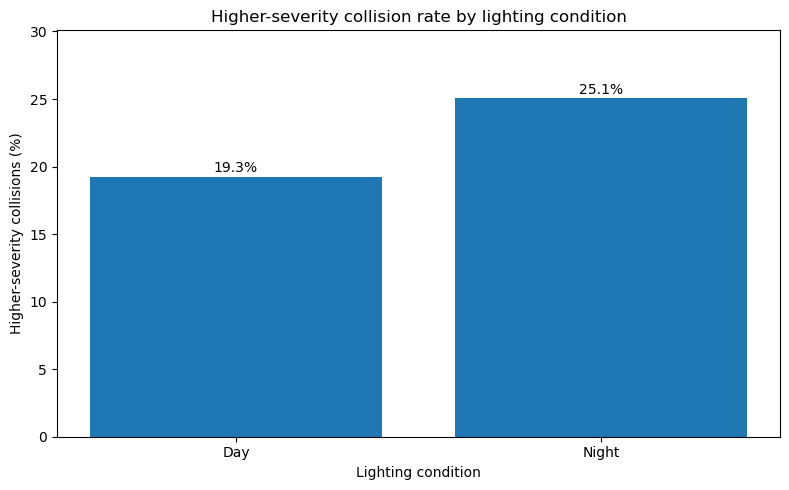

In [45]:
plot_data = night_summary.reset_index()

plt.figure(figsize=(8, 5))

plt.bar(
    plot_data["index"],
    plot_data["higher_severity_rate"]
)

plt.ylabel("Higher-severity collisions (%)")
plt.xlabel("Lighting condition")
plt.title("Higher-severity collision rate by lighting condition")
plt.ylim(0, max(plot_data["higher_severity_rate"]) * 1.2)

for i, value in enumerate(plot_data["higher_severity_rate"]):
    plt.text(i, value + 0.3, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

In [46]:
night_contingency = pd.crosstab(
    collision_analysis["is_night"],
    collision_analysis["severity_binary"]
)

night_contingency.index = [
    "Day",
    "Night"
]

night_contingency.columns = [
    "Lower severity",
    "Higher severity"
]

print(night_contingency)

       Lower severity  Higher severity
Day             16969             4048
Night           11076             3706


In [47]:

chi2, p_value, dof, expected = chi2_contingency(night_contingency)

print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", p_value)

Chi-square statistic: 172.325
Degrees of freedom: 1
p-value: 2.29785504736714e-39


In [48]:
n = night_contingency.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 / (n * min(night_contingency.shape[0] - 1,
                    night_contingency.shape[1] - 1))
)

print("Cramér's V:", round(cramers_v, 3))

Cramér's V: 0.069


In [49]:
expected_table = pd.DataFrame(
    expected,
    index=night_contingency.index,
    columns=night_contingency.columns
)

print(expected_table.round(2))

       Lower severity  Higher severity
Day          16464.76          4552.24
Night        11580.24          3201.76


In [50]:
weekend_summary = (
    collision_analysis
    .groupby("is_weekend")["severity_binary"]
    .agg(
        collisions="size",
        higher_severity="sum",
        higher_severity_rate="mean"
    )
)

weekend_summary["higher_severity_rate"] *= 100
weekend_summary.index = ["Weekday", "Weekend"]

print(weekend_summary.round(2))

         collisions  higher_severity  higher_severity_rate
Weekday       24453             5231                 21.39
Weekend       11346             2523                 22.24


In [51]:
weekday_rate = weekend_summary.loc["Weekday", "higher_severity_rate"]
weekend_rate = weekend_summary.loc["Weekend", "higher_severity_rate"]

difference_pp = weekend_rate - weekday_rate

print("Weekday higher-severity rate:", round(weekday_rate, 2), "%")
print("Weekend higher-severity rate:", round(weekend_rate, 2), "%")
print("Difference:", round(difference_pp, 2), "percentage points")

Weekday higher-severity rate: 21.39 %
Weekend higher-severity rate: 22.24 %
Difference: 0.84 percentage points


In [52]:
relative_risk_weekend = weekend_rate / weekday_rate

print(
    "Relative risk (weekend compared with weekday):",
    round(relative_risk_weekend, 3)
)

Relative risk (weekend compared with weekday): 1.039


In [53]:
weekend_contingency = pd.crosstab(
    collision_analysis["is_weekend"],
    collision_analysis["severity_binary"]
)

weekend_contingency.index = ["Weekday", "Weekend"]
weekend_contingency.columns = ["Lower severity", "Higher severity"]

print(weekend_contingency)

         Lower severity  Higher severity
Weekday           19222             5231
Weekend            8823             2523


In [54]:

chi2_weekend, p_value_weekend, dof_weekend, expected_weekend = (
    chi2_contingency(weekend_contingency)
)

print("Chi-square statistic:", round(chi2_weekend, 3))
print("Degrees of freedom:", dof_weekend)
print("p-value:", p_value_weekend)

Chi-square statistic: 3.21
Degrees of freedom: 1
p-value: 0.0731683151136008


In [55]:
n_weekend = weekend_contingency.to_numpy().sum()

cramers_v_weekend = np.sqrt(
    chi2_weekend /
    (
        n_weekend *
        min(
            weekend_contingency.shape[0] - 1,
            weekend_contingency.shape[1] - 1
        )
    )
)

print("Cramér's V:", round(cramers_v_weekend, 3))

Cramér's V: 0.009


In [56]:
expected_weekend_table = pd.DataFrame(
    expected_weekend,
    index=weekend_contingency.index,
    columns=weekend_contingency.columns
)

print(expected_weekend_table.round(2))

         Lower severity  Higher severity
Weekday        19156.52          5296.48
Weekend         8888.48          2457.52


In [57]:
sex_summary = (
    collision_analysis
    .groupby("driver_sex_collision")["severity_binary"]
    .agg(
        collisions="size",
        higher_severity="sum",
        higher_severity_rate="mean"
    )
)

sex_summary["higher_severity_rate"] *= 100

print(sex_summary.round(2))

                      collisions  higher_severity  higher_severity_rate
driver_sex_collision                                                   
Female only                11935             2188                 18.33
Male only                  23084             5422                 23.49
Mixed sex                    297               48                 16.16
Unknown                      483               96                 19.88


In [58]:
sex_contingency = pd.crosstab(
    collision_analysis["driver_sex_collision"],
    collision_analysis["severity_binary"]
)

sex_contingency.columns = ["Lower severity", "Higher severity"]

print(sex_contingency)

                      Lower severity  Higher severity
driver_sex_collision                                 
Female only                     9747             2188
Male only                      17662             5422
Mixed sex                        249               48
Unknown                          387               96


In [59]:
chi2_sex, p_value_sex, dof_sex, expected_sex = (
    chi2_contingency(sex_contingency)
)

print("Chi-square statistic:", round(chi2_sex, 3))
print("Degrees of freedom:", dof_sex)
print("p-value:", p_value_sex)

Chi-square statistic: 129.536
Degrees of freedom: 3
p-value: 6.808290491667494e-28


In [60]:
n_sex = sex_contingency.to_numpy().sum()

cramers_v_sex = np.sqrt(
    chi2_sex /
    (
        n_sex *
        min(
            sex_contingency.shape[0] - 1,
            sex_contingency.shape[1] - 1
        )
    )
)

print("Cramér's V:", round(cramers_v_sex, 3))

Cramér's V: 0.06


In [61]:
expected_sex_table = pd.DataFrame(
    expected_sex,
    index=sex_contingency.index,
    columns=sex_contingency.columns
)

print(expected_sex_table.round(2))

                      Lower severity  Higher severity
driver_sex_collision                                 
Female only                  9349.90          2585.10
Male only                   18084.05          4999.95
Mixed sex                     232.67            64.33
Unknown                       378.38           104.62


In [62]:
passenger_summary = (
    collision_analysis
    .groupby("young_car_passenger_present")["severity_binary"]
    .agg(
        collisions="size",
        higher_severity="sum",
        higher_severity_rate="mean"
    )
)

passenger_summary["higher_severity_rate"] *= 100
passenger_summary.index = ["No young passenger", "Young passenger present"]

print(passenger_summary.round(2))

                         collisions  higher_severity  higher_severity_rate
No young passenger            27943             5441                 19.47
Young passenger present        7856             2313                 29.44


In [63]:
passenger_contingency = pd.crosstab(
    collision_analysis["young_car_passenger_present"],
    collision_analysis["severity_binary"]
)

passenger_contingency.index = [
    "No young passenger",
    "Young passenger present"
]

passenger_contingency.columns = [
    "Lower severity",
    "Higher severity"
]

print(passenger_contingency)

                         Lower severity  Higher severity
No young passenger                22502             5441
Young passenger present            5543             2313


In [64]:
no_passenger_rate = passenger_summary.loc[
    "No young passenger",
    "higher_severity_rate"
]

passenger_rate = passenger_summary.loc[
    "Young passenger present",
    "higher_severity_rate"
]

difference_pp_passenger = passenger_rate - no_passenger_rate

relative_risk_passenger = passenger_rate / no_passenger_rate

print(
    "No young passenger higher-severity rate:",
    round(no_passenger_rate, 2), "%"
)

print(
    "Young passenger present higher-severity rate:",
    round(passenger_rate, 2), "%"
)

print(
    "Difference:",
    round(difference_pp_passenger, 2),
    "percentage points"
)

print(
    "Relative risk:",
    round(relative_risk_passenger, 3)
)

No young passenger higher-severity rate: 19.47 %
Young passenger present higher-severity rate: 29.44 %
Difference: 9.97 percentage points
Relative risk: 1.512


In [65]:
chi2_passenger, p_value_passenger, dof_passenger, expected_passenger = (
    chi2_contingency(passenger_contingency)
)

print("Chi-square statistic:", round(chi2_passenger, 3))
print("Degrees of freedom:", dof_passenger)
print("p-value:", p_value_passenger)

Chi-square statistic: 358.677
Degrees of freedom: 1
p-value: 5.466407692730984e-80


In [66]:
n_passenger = passenger_contingency.to_numpy().sum()

cramers_v_passenger = np.sqrt(
    chi2_passenger /
    (
        n_passenger *
        min(
            passenger_contingency.shape[0] - 1,
            passenger_contingency.shape[1] - 1
        )
    )
)

print("Cramér's V:", round(cramers_v_passenger, 3))

Cramér's V: 0.1


In [67]:
expected_passenger_table = pd.DataFrame(
    expected_passenger,
    index=passenger_contingency.index,
    columns=passenger_contingency.columns
)

print(expected_passenger_table.round(2))

                         Lower severity  Higher severity
No young passenger              21890.6           6052.4
Young passenger present          6154.4           1701.6


In [68]:
vehicle_summary = (
    driver_analysis[
        driver_analysis["vehicle_age_band"] != "Unknown"
    ]
    .groupby("vehicle_age_band")["severity_binary"]
    .agg(
        records="size",
        higher_severity="sum",
        higher_severity_rate="mean"
    )
)

vehicle_summary["higher_severity_rate"] *= 100

vehicle_order = [
    "0–3",
    "4–7",
    "8–12",
    "13–18",
    "19+"
]

vehicle_summary = vehicle_summary.reindex(vehicle_order)

print(vehicle_summary.round(2))

                  records  higher_severity  higher_severity_rate
vehicle_age_band                                                
0–3                  3682              721                 19.58
4–7                  6193             1311                 21.17
8–12                11773             2474                 21.01
13–18               10269             2320                 22.59
19+                  1456              348                  23.9


In [69]:
vehicle_contingency = pd.crosstab(
    driver_analysis.loc[
        driver_analysis["vehicle_age_band"] != "Unknown",
        "vehicle_age_band"
    ],
    driver_analysis.loc[
        driver_analysis["vehicle_age_band"] != "Unknown",
        "severity_binary"
    ]
)

vehicle_contingency = vehicle_contingency.reindex(vehicle_order)

vehicle_contingency.columns = [
    "Lower severity",
    "Higher severity"
]

print(vehicle_contingency)

                  Lower severity  Higher severity
vehicle_age_band                                 
0–3                         2961              721
4–7                         4882             1311
8–12                        9299             2474
13–18                       7949             2320
19+                         1108              348


In [70]:
chi2_vehicle, p_value_vehicle, dof_vehicle, expected_vehicle = (
    chi2_contingency(vehicle_contingency)
)

print("Chi-square statistic:", round(chi2_vehicle, 3))
print("Degrees of freedom:", dof_vehicle)
print("p-value:", p_value_vehicle)

Chi-square statistic: 22.311
Degrees of freedom: 4
p-value: 0.0001737858276689322


In [71]:
n_vehicle = vehicle_contingency.to_numpy().sum()

cramers_v_vehicle = np.sqrt(
    chi2_vehicle /
    (
        n_vehicle *
        min(
            vehicle_contingency.shape[0] - 1,
            vehicle_contingency.shape[1] - 1
        )
    )
)

print("Cramér's V:", round(cramers_v_vehicle, 3))

Cramér's V: 0.026


In [72]:
expected_vehicle_table = pd.DataFrame(
    expected_vehicle,
    index=vehicle_contingency.index,
    columns=vehicle_contingency.columns
)

print(expected_vehicle_table.round(2))

                  Lower severity  Higher severity
vehicle_age_band                                 
0–3                      2890.50           791.50
4–7                      4861.73          1331.27
8–12                     9242.23          2530.77
13–18                    8061.53          2207.47
19+                      1143.01           312.99


In [73]:
model_data = driver_analysis[
    driver_analysis["vehicle_age_band"] != "Unknown"
].copy()

print("Records available for combined model:", len(model_data))
print("Unique collisions:", model_data["collision_index"].nunique())

Records available for combined model: 33373
Unique collisions: 32704


In [74]:
print("\nVehicle age:")
print(model_data["vehicle_age_band"].value_counts())

print("\nNight/day:")
print(model_data["is_night"].value_counts())

print("\nWeekday/weekend:")
print(model_data["is_weekend"].value_counts())

print("\nYoung passenger:")
print(model_data["young_car_passenger_present"].value_counts())

print("\nDriver sex:")
print(model_data["driver_sex_collision"].value_counts())


Vehicle age:
vehicle_age_band
8–12     11773
13–18    10269
4–7       6193
0–3       3682
19+       1456
Name: count, dtype: int64

Night/day:
is_night
0    19580
1    13793
Name: count, dtype: Int64

Weekday/weekend:
is_weekend
0    22790
1    10583
Name: count, dtype: Int64

Young passenger:
young_car_passenger_present
0    25851
1     7522
Name: count, dtype: int64

Driver sex:
driver_sex_collision
Male only      21258
Female only    11279
Mixed sex        554
Unknown          282
Name: count, dtype: int64


In [75]:
model_variables = [
    "severity_binary",
    "is_night",
    "is_weekend",
    "young_car_passenger_present",
    "driver_sex_collision",
    "vehicle_age_band"
]

print(model_data[model_variables].isna().sum())

severity_binary                0
is_night                       0
is_weekend                     0
young_car_passenger_present    0
driver_sex_collision           0
vehicle_age_band               0
dtype: int64


In [76]:
vehicle_age_per_collision = (
    driver_analysis
    .groupby("collision_index")["vehicle_age_band"]
    .nunique()
)

print("Collisions with one vehicle-age band:",
      (vehicle_age_per_collision == 1).sum())

print("Collisions with multiple vehicle-age bands:",
      (vehicle_age_per_collision > 1).sum())

print("Total collisions:",
      len(vehicle_age_per_collision))

Collisions with one vehicle-age band: 35252
Collisions with multiple vehicle-age bands: 547
Total collisions: 35799


In [77]:
multi_vehicle_age_collisions = vehicle_age_per_collision[
    vehicle_age_per_collision > 1
]

print(multi_vehicle_age_collisions.value_counts().sort_index())

vehicle_age_band
2    537
3     10
Name: count, dtype: int64


In [78]:
vehicle_age_known = driver_analysis[
    driver_analysis["vehicle_age_band"] != "Unknown"
].copy()

known_age_per_collision = (
    vehicle_age_known
    .groupby("collision_index")["vehicle_age_band"]
    .nunique()
)

print(
    "Collisions with multiple known vehicle-age bands:",
    (known_age_per_collision > 1).sum()
)

Collisions with multiple known vehicle-age bands: 459


In [79]:
collision_model_data = collision_analysis.copy()

print(collision_model_data.shape)
print(collision_model_data.isna().sum())

(35799, 7)
collision_index                0
collision_year_collision       0
severity_binary                0
is_night                       0
is_weekend                     0
driver_sex_collision           0
young_car_passenger_present    0
dtype: int64


In [80]:
collision_model_data["lighting"] = (
    collision_model_data["is_night"]
    .map({0: "Day", 1: "Night"})
)

collision_model_data["day_type"] = (
    collision_model_data["is_weekend"]
    .map({0: "Weekday", 1: "Weekend"})
)

collision_model_data["passenger"] = (
    collision_model_data["young_car_passenger_present"]
    .map({0: "No young passenger", 1: "Young passenger present"})
)

collision_model_data["lighting"] = pd.Categorical(
    collision_model_data["lighting"],
    categories=["Day", "Night"]
)

collision_model_data["day_type"] = pd.Categorical(
    collision_model_data["day_type"],
    categories=["Weekday", "Weekend"]
)

collision_model_data["passenger"] = pd.Categorical(
    collision_model_data["passenger"],
    categories=["No young passenger", "Young passenger present"]
)

collision_model_data["driver_sex_collision"] = pd.Categorical(
    collision_model_data["driver_sex_collision"],
    categories=[
        "Female only",
        "Male only",
        "Mixed sex",
        "Unknown"
    ]
)

## 5. Multivariable logistic regression

The descriptive and chi-square analyses examine characteristics individually. Logistic regression is then used to examine whether the observed associations remain after accounting for the other selected collision characteristics simultaneously.

The dependent variable is binary collision severity. The reference categories are Day, Weekday, No young passenger and Female only.

Odds ratios above 1 indicate higher estimated odds of a higher-severity collision relative to the reference category, while odds ratios below 1 indicate lower estimated odds. The model describes adjusted associations and is not interpreted as evidence of causation.

In [81]:
logit_model = smf.logit(
    """
    severity_binary ~
    C(lighting, Treatment(reference="Day")) +
    C(day_type, Treatment(reference="Weekday")) +
    C(passenger, Treatment(reference="No young passenger")) +
    C(driver_sex_collision, Treatment(reference="Female only"))
    """,
    data=collision_model_data
).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.515254
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        severity_binary   No. Observations:                35799
Model:                          Logit   Df Residuals:                    35792
Method:                           MLE   Df Model:                            6
Date:                Wed, 09 Sep 2026   Pseudo R-squ.:                 0.01400
Time:                        12:05:38   Log-Likelihood:                -18446.
converged:                       True   LL-Null:                       -18707.
Covariance Type:            nonrobust   LLR p-value:                6.496e-110
                                                                                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------

In [82]:
odds_ratios = np.exp(logit_model.params)

print(odds_ratios.round(3))

Intercept                                                                             0.186
C(lighting, Treatment(reference="Day"))[T.Night]                                      1.268
C(day_type, Treatment(reference="Weekday"))[T.Weekend]                                1.022
C(passenger, Treatment(reference="No young passenger"))[T.Young passenger present]    1.604
C(driver_sex_collision, Treatment(reference="Female only"))[T.Male only]              1.286
C(driver_sex_collision, Treatment(reference="Female only"))[T.Mixed sex]              0.768
C(driver_sex_collision, Treatment(reference="Female only"))[T.Unknown]                1.162
dtype: float64


In [83]:
logit_results = pd.DataFrame({
    "Odds ratio": np.exp(logit_model.params),
    "CI lower": np.exp(logit_model.conf_int()[0]),
    "CI upper": np.exp(logit_model.conf_int()[1]),
    "p-value": logit_model.pvalues
})

print(logit_results.round(3))

                                                    Odds ratio  CI lower  \
Intercept                                                0.186     0.177   
C(lighting, Treatment(reference="Day"))[T.Night]         1.268     1.204   
C(day_type, Treatment(reference="Weekday"))[T.W...       1.022     0.968   
C(passenger, Treatment(reference="No young pass...       1.604     1.513   
C(driver_sex_collision, Treatment(reference="Fe...       1.286     1.216   
C(driver_sex_collision, Treatment(reference="Fe...       0.768     0.561   
C(driver_sex_collision, Treatment(reference="Fe...       1.162     0.924   

                                                    CI upper  p-value  
Intercept                                              0.197    0.000  
C(lighting, Treatment(reference="Day"))[T.Night]       1.336    0.000  
C(day_type, Treatment(reference="Weekday"))[T.W...     1.079    0.436  
C(passenger, Treatment(reference="No young pass...     1.700    0.000  
C(driver_sex_collision, Treatme

In [84]:

collision_model_data["predicted_probability"] = (
    logit_model.predict(collision_model_data)
)

collision_model_data["predicted_class"] = (
    collision_model_data["predicted_probability"] >= 0.5
).astype(int)

y_true = collision_model_data["severity_binary"]
y_pred = collision_model_data["predicted_class"]
y_prob = collision_model_data["predicted_probability"]

print("Accuracy:", round(accuracy_score(y_true, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_true, y_prob), 3))

Accuracy: 0.783
ROC-AUC: 0.578


In [85]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion matrix:")
print(cm)

Confusion matrix:
[[28045     0]
 [ 7754     0]]


In [86]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Lower severity", "Higher severity"],
        digits=3
    )
)

                 precision    recall  f1-score   support

 Lower severity      0.783     1.000     0.879     28045
Higher severity      0.000     0.000     0.000      7754

       accuracy                          0.783     35799
      macro avg      0.392     0.500     0.439     35799
   weighted avg      0.614     0.783     0.688     35799



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Supplementary driver–vehicle-level model

Vehicle age is not included in the primary collision-level logistic regression because it is recorded for individual vehicles and cannot always be uniquely assigned to a collision when more than one qualifying young driver is present.

A supplementary driver–vehicle-level model is therefore fitted to records with known vehicle age. This provides an additional assessment of vehicle age while recognising that multiple records can belong to the same collision.

In [87]:
vehicle_model_data = driver_analysis[
    driver_analysis["vehicle_age_band"] != "Unknown"
].copy()

vehicle_model_data["lighting"] = (
    vehicle_model_data["is_night"]
    .map({0: "Day", 1: "Night"})
)

vehicle_model_data["day_type"] = (
    vehicle_model_data["is_weekend"]
    .map({0: "Weekday", 1: "Weekend"})
)

vehicle_model_data["passenger"] = (
    vehicle_model_data["young_car_passenger_present"]
    .map({0: "No young passenger", 1: "Young passenger present"})
)

vehicle_model_data["lighting"] = pd.Categorical(
    vehicle_model_data["lighting"],
    categories=["Day", "Night"]
)

vehicle_model_data["day_type"] = pd.Categorical(
    vehicle_model_data["day_type"],
    categories=["Weekday", "Weekend"]
)

vehicle_model_data["passenger"] = pd.Categorical(
    vehicle_model_data["passenger"],
    categories=["No young passenger", "Young passenger present"]
)

vehicle_model_data["driver_sex_collision"] = pd.Categorical(
    vehicle_model_data["driver_sex_collision"],
    categories=[
        "Female only",
        "Male only",
        "Mixed sex",
        "Unknown"
    ]
)

vehicle_model_data["vehicle_age_band"] = pd.Categorical(
    vehicle_model_data["vehicle_age_band"],
    categories=[
        "0–3",
        "4–7",
        "8–12",
        "13–18",
        "19+"
    ]
)

print(vehicle_model_data.shape)
print(vehicle_model_data.isna().sum())

(33373, 48)
collision_index                              0
collision_year_collision                     0
collision_severity                           0
time                                         0
light_conditions                             0
day_of_week                                  0
local_authority_ons_district                 0
collision_year_vehicle                       0
collision_ref_no                             0
vehicle_reference                            0
vehicle_type                                 0
towing_and_articulation                      0
vehicle_manoeuvre_historic                   0
vehicle_manoeuvre                            0
vehicle_direction_from                       0
vehicle_direction_to                         0
vehicle_location_restricted_lane_historic    0
vehicle_location_restricted_lane             0
junction_location                            0
skidding_and_overturning                     0
hit_object_in_carriageway                    0
v

In [88]:
vehicle_logit_model = smf.logit(
    """
    severity_binary ~
    C(lighting, Treatment(reference="Day")) +
    C(day_type, Treatment(reference="Weekday")) +
    C(passenger, Treatment(reference="No young passenger")) +
    C(driver_sex_collision, Treatment(reference="Female only")) +
    C(vehicle_age_band, Treatment(reference="0–3"))
    """,
    data=vehicle_model_data
).fit()

print(vehicle_logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.512535
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        severity_binary   No. Observations:                33373
Model:                          Logit   Df Residuals:                    33362
Method:                           MLE   Df Model:                           10
Date:                Wed, 09 Sep 2026   Pseudo R-squ.:                 0.01523
Time:                        12:05:38   Log-Likelihood:                -17105.
converged:                       True   LL-Null:                       -17369.
Covariance Type:            nonrobust   LLR p-value:                2.797e-107
                                                                                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------

In [89]:
vehicle_logit_results = pd.DataFrame({
    "Odds ratio": np.exp(vehicle_logit_model.params),
    "CI lower": np.exp(vehicle_logit_model.conf_int()[0]),
    "CI upper": np.exp(vehicle_logit_model.conf_int()[1]),
    "p-value": vehicle_logit_model.pvalues
})

print(vehicle_logit_results.round(3))

                                                    Odds ratio  CI lower  \
Intercept                                                0.169     0.153   
C(lighting, Treatment(reference="Day"))[T.Night]         1.274     1.207   
C(day_type, Treatment(reference="Weekday"))[T.W...       1.040     0.984   
C(passenger, Treatment(reference="No young pass...       1.615     1.521   
C(driver_sex_collision, Treatment(reference="Fe...       1.276     1.204   
C(driver_sex_collision, Treatment(reference="Fe...       0.785     0.623   
C(driver_sex_collision, Treatment(reference="Fe...       0.906     0.658   
C(vehicle_age_band, Treatment(reference="0–3"))...       1.103     0.995   
C(vehicle_age_band, Treatment(reference="0–3"))...       1.067     0.972   
C(vehicle_age_band, Treatment(reference="0–3"))...       1.135     1.033   
C(vehicle_age_band, Treatment(reference="0–3"))...       1.187     1.025   

                                                    CI upper  p-value  
Intercept      

## 6. Predictive modelling

The machine-learning analysis addresses a different question from the inferential analysis.

The logistic regression examines adjusted statistical associations, whereas the predictive models assess whether the selected characteristics can discriminate between lower- and higher-severity collisions for previously unseen observations.

The primary machine-learning dataset is therefore collision-level and excludes vehicle age because vehicle age cannot always be uniquely represented at collision level.

The data are divided into training and held-out test sets using an 80:20 stratified split. Stratification preserves the proportion of higher- and lower-severity collisions in both sets.

ROC-AUC is used as the principal predictive metric because the outcome classes are imbalanced. Accuracy is also reported but is interpreted cautiously because a model can achieve high accuracy by predominantly predicting the majority class.

In [90]:
ml_data = collision_analysis[
    [
        "severity_binary",
        "is_night",
        "is_weekend",
        "young_car_passenger_present",
        "driver_sex_collision"
    ]
].copy()

print("ML dataset shape:", ml_data.shape)
print("\nTarget distribution:")
print(ml_data["severity_binary"].value_counts())
print("\nPredictor missing values:")
print(ml_data.isna().sum())

ML dataset shape: (35799, 5)

Target distribution:
severity_binary
0    28045
1     7754
Name: count, dtype: Int64

Predictor missing values:
severity_binary                0
is_night                       0
is_weekend                     0
young_car_passenger_present    0
driver_sex_collision           0
dtype: int64


In [91]:
X = pd.get_dummies(
    ml_data.drop(columns="severity_binary"),
    columns=["driver_sex_collision"],
    drop_first=True,
    dtype=int
)

y = ml_data["severity_binary"]

print("Predictor columns:")
print(X.columns.tolist())
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Predictor columns:
['is_night', 'is_weekend', 'young_car_passenger_present', 'driver_sex_collision_Male only', 'driver_sex_collision_Mixed sex', 'driver_sex_collision_Unknown']

X shape: (35799, 6)
y shape: (35799,)


In [92]:
print(X.head())
print("\nMissing values:")
print(X.isna().sum())

   is_night  is_weekend  young_car_passenger_present  \
0         0           0                            0   
1         1           0                            0   
2         0           0                            0   
3         0           1                            1   
4         1           1                            1   

   driver_sex_collision_Male only  driver_sex_collision_Mixed sex  \
0                               0                               0   
1                               1                               0   
2                               1                               0   
3                               1                               0   
4                               1                               0   

   driver_sex_collision_Unknown  
0                             0  
1                             0  
2                             0  
3                             0  
4                             0  

Missing values:
is_night                   

In [93]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training observations: 28639
Test observations: 7160

Training target distribution:
severity_binary
0    0.783
1    0.217
Name: proportion, dtype: Float64

Test target distribution:
severity_binary
0    0.783
1    0.217
Name: proportion, dtype: Float64


In [94]:

decision_tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision tree trained successfully.")
print("Tree depth:", decision_tree.get_depth())
print("Number of leaves:", decision_tree.get_n_leaves())

Decision tree trained successfully.
Tree depth: 4
Number of leaves: 16


In [95]:

tree_pred = decision_tree.predict(X_test)
tree_prob = decision_tree.predict_proba(X_test)[:, 1]

print("Decision tree accuracy:",
      round(accuracy_score(y_test, tree_pred), 3))

print("Decision tree ROC-AUC:",
      round(roc_auc_score(y_test, tree_prob), 3))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, tree_pred))

print("\nClassification report:")
print(
    classification_report(
        y_test,
        tree_pred,
        target_names=["Lower severity", "Higher severity"],
        digits=3
    )
)


Decision tree accuracy: 0.783
Decision tree ROC-AUC: 0.57

Confusion matrix:
[[5607    2]
 [1551    0]]

Classification report:
                 precision    recall  f1-score   support

 Lower severity      0.783     1.000     0.878      5609
Higher severity      0.000     0.000     0.000      1551

       accuracy                          0.783      7160
      macro avg      0.392     0.500     0.439      7160
   weighted avg      0.614     0.783     0.688      7160



In [96]:
tree_importance = pd.Series(
    decision_tree.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(tree_importance.round(3))

young_car_passenger_present       0.642
is_night                          0.182
driver_sex_collision_Male only    0.126
is_weekend                        0.037
driver_sex_collision_Mixed sex    0.007
driver_sex_collision_Unknown      0.006
dtype: float64


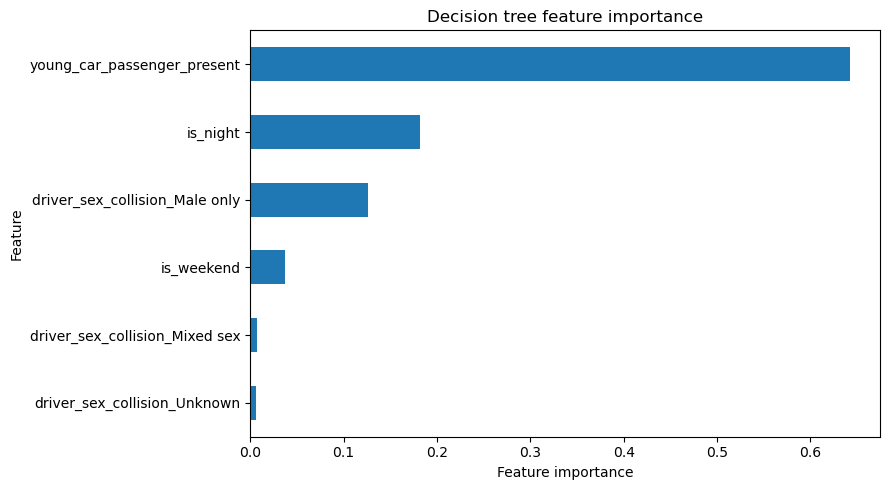

In [97]:
plt.figure(figsize=(9, 5))

tree_importance.sort_values().plot(kind="barh")

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Decision tree feature importance")

plt.tight_layout()
plt.show()

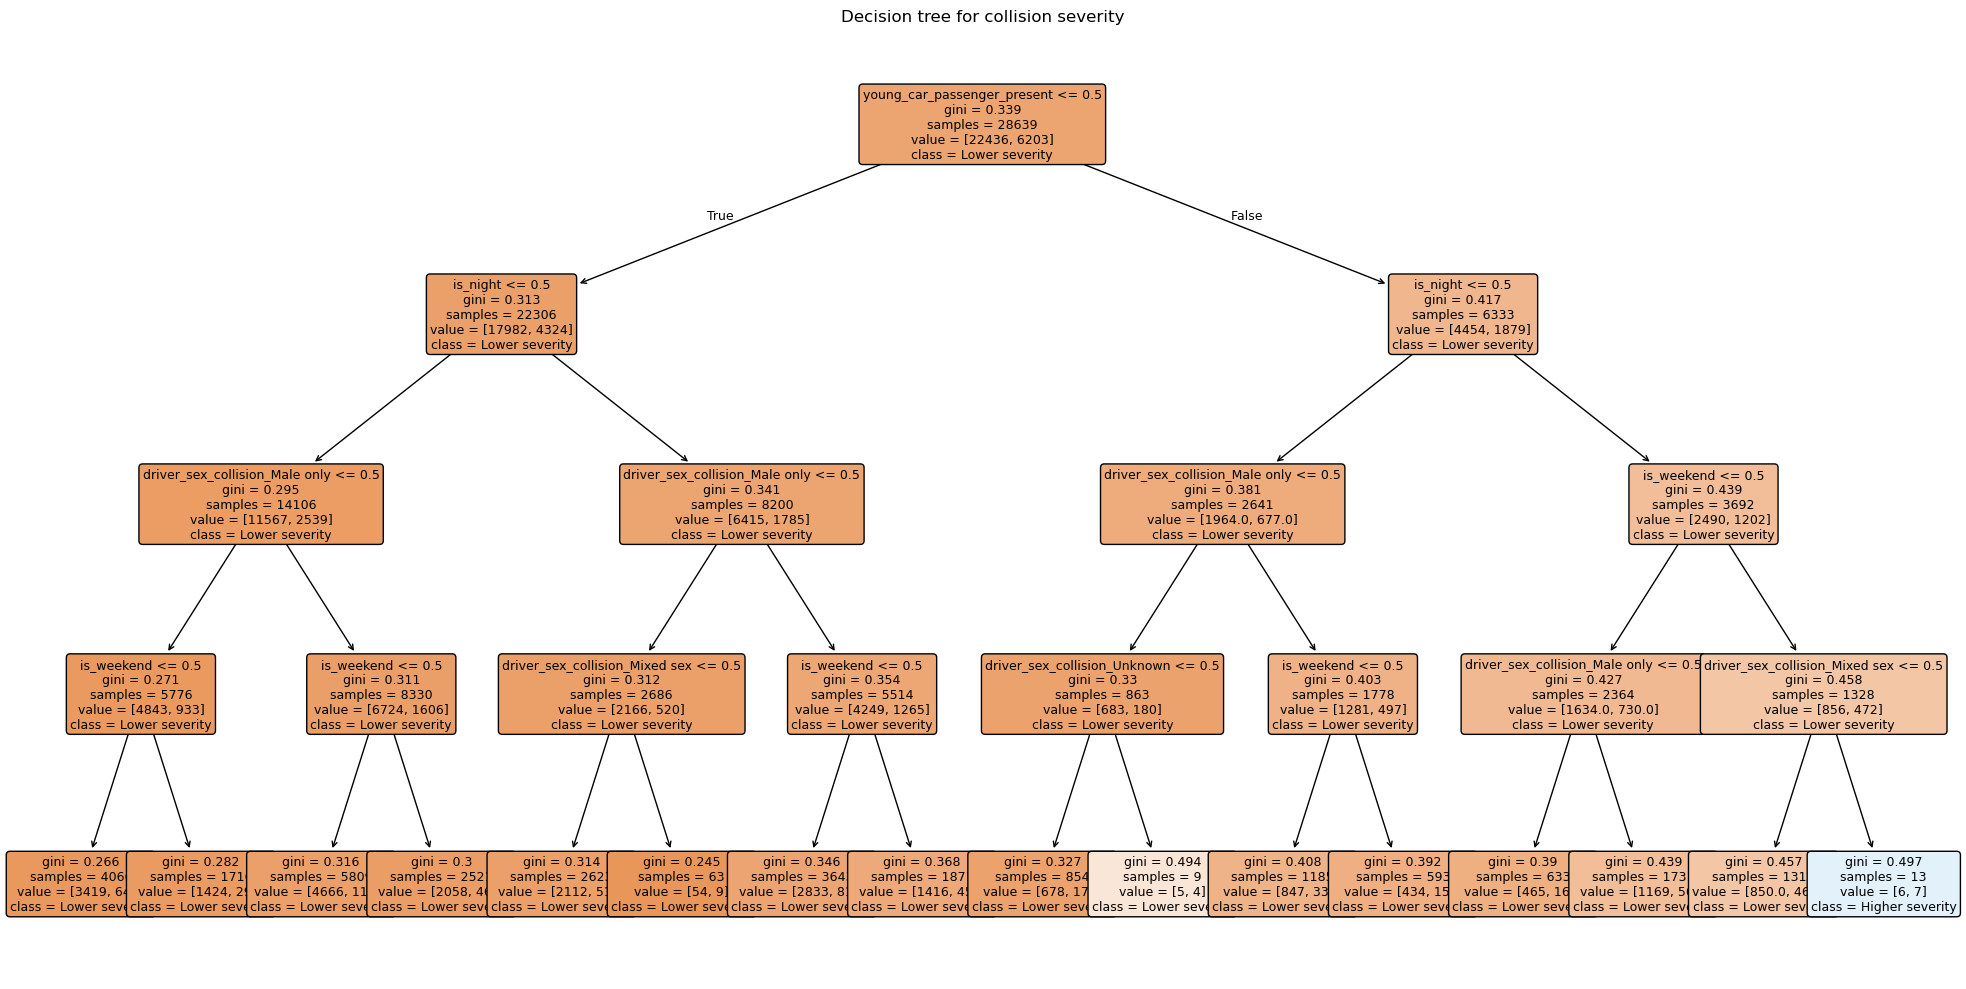

In [98]:

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree,
    feature_names=X.columns,
    class_names=["Lower severity", "Higher severity"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision tree for collision severity")
plt.tight_layout()
plt.show()

### Decision-tree model selection

A maximum tree depth of four is selected using five-fold stratified cross-validation on the training data.

Increasing the depth beyond four produces no meaningful improvement in mean ROC-AUC. The depth-four model is therefore retained as a relatively simple model that captures the observed structure without adding unnecessary complexity.

In [99]:

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

depth_results = []

for depth in range(1, 9):
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    scores = cross_val_score(
        tree,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc"
    )
    
    depth_results.append({
        "max_depth": depth,
        "mean_roc_auc": scores.mean(),
        "std_roc_auc": scores.std()
    })

depth_results = pd.DataFrame(depth_results)

print(depth_results.round(3))

   max_depth  mean_roc_auc  std_roc_auc
0          1         0.552        0.008
1          2         0.568        0.012
2          3         0.578        0.012
3          4         0.579        0.010
4          5         0.579        0.011
5          6         0.579        0.010
6          7         0.579        0.010
7          8         0.579        0.010


In [100]:

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [101]:

rf_pred = random_forest.predict(X_test)
rf_prob = random_forest.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, rf_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 3))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, rf_pred))
print("\nClassification report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Lower severity", "Higher severity"],
    zero_division=0
))


Accuracy: 0.783
ROC-AUC: 0.57

Confusion matrix:
[[5605    4]
 [1550    1]]

Classification report:
                 precision    recall  f1-score   support

 Lower severity       0.78      1.00      0.88      5609
Higher severity       0.20      0.00      0.00      1551

       accuracy                           0.78      7160
      macro avg       0.49      0.50      0.44      7160
   weighted avg       0.66      0.78      0.69      7160



In [102]:
rf_importance = pd.Series(
    random_forest.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(rf_importance.round(3))

young_car_passenger_present       0.547
is_night                          0.221
driver_sex_collision_Male only    0.145
is_weekend                        0.047
driver_sex_collision_Unknown      0.022
driver_sex_collision_Mixed sex    0.018
dtype: float64


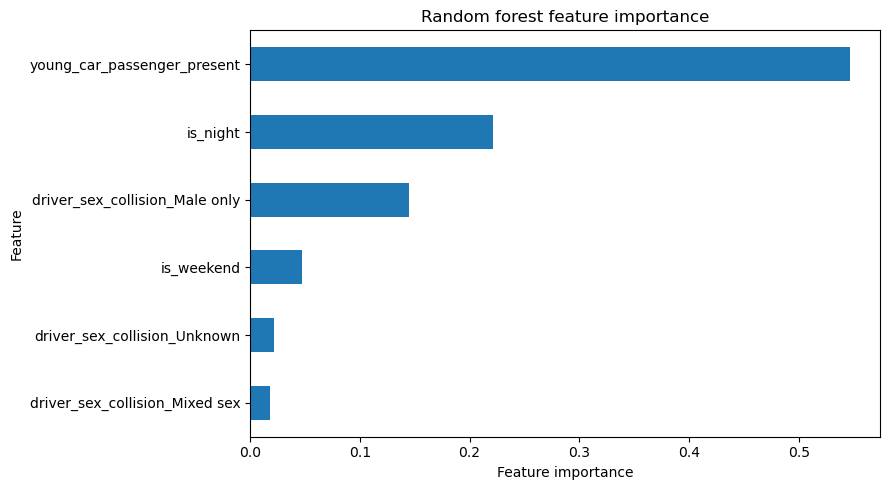

In [103]:
plt.figure(figsize=(9, 5))

rf_importance.sort_values().plot(kind="barh")

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Random forest feature importance")
plt.tight_layout()
plt.show()

In [104]:
balanced_forest = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

balanced_forest.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [105]:
balanced_pred = balanced_forest.predict(X_test)
balanced_prob = balanced_forest.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, balanced_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, balanced_prob), 3))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, balanced_pred))

print("\nClassification report:")
print(classification_report(
    y_test,
    balanced_pred,
    target_names=["Lower severity", "Higher severity"],
    zero_division=0
))


Accuracy: 0.608
ROC-AUC: 0.57

Confusion matrix:
[[3632 1977]
 [ 830  721]]

Classification report:
                 precision    recall  f1-score   support

 Lower severity       0.81      0.65      0.72      5609
Higher severity       0.27      0.46      0.34      1551

       accuracy                           0.61      7160
      macro avg       0.54      0.56      0.53      7160
   weighted avg       0.70      0.61      0.64      7160



In [106]:

logistic_ml = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_ml.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [107]:
logistic_pred = logistic_ml.predict(X_test)
logistic_prob = logistic_ml.predict_proba(X_test)[:, 1]

print("Accuracy:", round(
    accuracy_score(y_test, logistic_pred), 3
))

print("ROC-AUC:", round(
    roc_auc_score(y_test, logistic_prob), 3
))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, logistic_pred))

print("\nClassification report:")
print(classification_report(
    y_test,
    logistic_pred,
    target_names=["Lower severity", "Higher severity"],
    zero_division=0
))

Accuracy: 0.783
ROC-AUC: 0.567

Confusion matrix:
[[5609    0]
 [1551    0]]

Classification report:
                 precision    recall  f1-score   support

 Lower severity       0.78      1.00      0.88      5609
Higher severity       0.00      0.00      0.00      1551

       accuracy                           0.78      7160
      macro avg       0.39      0.50      0.44      7160
   weighted avg       0.61      0.78      0.69      7160



### Predictive model comparison

Logistic regression, a decision tree and a random forest are compared using the same five-fold stratified cross-validation procedure and ROC-AUC metric.

The purpose is not to identify the most complex model, but to determine whether additional model complexity provides materially better discrimination using the selected characteristics.

In [108]:

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Decision tree": DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ),
    "Random forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc"
    )
    
    cv_results.append({
        "model": name,
        "mean_roc_auc": scores.mean(),
        "std_roc_auc": scores.std()
    })

cv_results = pd.DataFrame(cv_results)

print(cv_results.round(3))

                 model  mean_roc_auc  std_roc_auc
0  Logistic regression         0.578        0.012
1        Decision tree         0.579        0.010
2        Random forest         0.579        0.010


In [109]:
print("=== FINAL DATA VALIDATION ===")

# Collision-level dataset
assert len(collision_analysis) == 35799
assert collision_analysis["collision_index"].nunique() == len(collision_analysis)
assert collision_analysis.isna().sum().sum() == 0

# Driver–vehicle dataset
assert len(driver_analysis) == 36586
assert driver_analysis["collision_index"].nunique() == 35799

# Machine-learning dataset
assert len(ml_data) == 35799
assert ml_data.isna().sum().sum() == 0

# Train/test split
assert len(X_train) + len(X_test) == len(ml_data)
assert len(y_train) + len(y_test) == len(ml_data)

print("Collision-level rows:", len(collision_analysis))
print(
    "Unique collisions:",
    collision_analysis["collision_index"].nunique()
)

print("Driver–vehicle rows:", len(driver_analysis))
print(
    "Driver–vehicle unique collisions:",
    driver_analysis["collision_index"].nunique()
)

print(
    "Higher-severity collisions:",
    (collision_analysis["severity_binary"] == 1).sum()
)

print(
    "Lower-severity collisions:",
    (collision_analysis["severity_binary"] == 0).sum()
)

print("ML rows:", len(ml_data))
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nAll final validation checks passed.")

=== FINAL DATA VALIDATION ===
Collision-level rows: 35799
Unique collisions: 35799
Driver–vehicle rows: 36586
Driver–vehicle unique collisions: 35799
Higher-severity collisions: 7754
Lower-severity collisions: 28045
ML rows: 35799
Training rows: 28639
Test rows: 7160

All final validation checks passed.


## Combined collision profiles

The combined-profile analysis examines naturally occurring combinations of the selected characteristics. Because vehicle age is recorded at driver–vehicle level, the profile analysis is restricted to collisions containing one qualifying young driver and a known vehicle age. This ensures that each profile represents one clearly attributable driver–vehicle observation per collision.

The analysis is descriptive and is used to examine how observed higher-severity proportions vary across combinations. It is not interpreted causally.

Profiles containing fewer than 100 collisions are excluded from the final ranking to reduce the influence of very small groups. This threshold is a descriptive reporting rule rather than a statistical significance test.

In [110]:
# Identify collisions containing exactly one qualifying young driver
driver_count_per_collision = (
    analysis_data
    .groupby("collision_index")
    .size()
)

profile_data = driver_analysis.copy()

profile_data["qualifying_driver_count"] = (
    profile_data["collision_index"]
    .map(driver_count_per_collision)
)

# Retain only:
# 1. collisions with one qualifying young driver
# 2. known vehicle age
profile_data = profile_data[
    (profile_data["qualifying_driver_count"] == 1) &
    (profile_data["vehicle_age_band"] != "Unknown")
].copy()

print("Combined-profile records:", len(profile_data))
print(
    "Unique collisions:",
    profile_data["collision_index"].nunique()
)

Combined-profile records: 31964
Unique collisions: 31964


In [111]:
profile_variables = [
    "severity_binary",
    "is_night",
    "is_weekend",
    "sex_of_driver",
    "vehicle_age_band",
    "young_car_passenger_present"
]

print(profile_data[profile_variables].isna().sum())

severity_binary                0
is_night                       0
is_weekend                     0
sex_of_driver                  0
vehicle_age_band               0
young_car_passenger_present    0
dtype: int64


In [112]:
print("\nDriver sex:")
print(profile_data["sex_of_driver"].value_counts().sort_index())

print("\nVehicle age:")
print(profile_data["vehicle_age_band"].value_counts().sort_index())

print("\nNight:")
print(profile_data["is_night"].value_counts().sort_index())

print("\nWeekend:")
print(profile_data["is_weekend"].value_counts().sort_index())

print("\nYoung passenger:")
print(
    profile_data["young_car_passenger_present"]
    .value_counts()
    .sort_index()
)


Driver sex:
sex_of_driver
-1       13
 1    20605
 2    11077
 3      269
Name: count, dtype: int64

Vehicle age:
vehicle_age_band
0–3       3508
13–18     9860
19+       1398
4–7       5913
8–12     11285
Name: count, dtype: int64

Night:
is_night
0    18891
1    13073
Name: count, dtype: Int64

Weekend:
is_weekend
0    21867
1    10097
Name: count, dtype: Int64

Young passenger:
young_car_passenger_present
0    24995
1     6969
Name: count, dtype: int64


In [113]:
profile_data["driver_sex_profile"] = (
    profile_data["sex_of_driver"]
    .map({
        1: "Male",
        2: "Female"
    })
)

In [114]:
print(
    profile_data["driver_sex_profile"]
    .value_counts(dropna=False)
)

driver_sex_profile
Male      20605
Female    11077
NaN         282
Name: count, dtype: int64


In [115]:
profile_data = profile_data[
    profile_data["driver_sex_profile"].isin(["Male", "Female"])
].copy()

print("Profile dataset after driver-sex restriction:")
print(profile_data.shape)
print(
    "Unique collisions:",
    profile_data["collision_index"].nunique()
)

Profile dataset after driver-sex restriction:
(31682, 47)
Unique collisions: 31682


In [116]:
profile_data["vehicle_age_profile"] = np.where(
    profile_data["age_of_vehicle"].between(0, 12),
    "Under 13",
    "13+"
)

In [117]:
print(
    profile_data["vehicle_age_profile"]
    .value_counts()
)

vehicle_age_profile
Under 13    20524
13+         11158
Name: count, dtype: int64


In [118]:
profile_data["lighting_profile"] = (
    profile_data["is_night"]
    .map({
        0: "Day",
        1: "Night"
    })
)

profile_data["day_profile"] = (
    profile_data["is_weekend"]
    .map({
        0: "Weekday",
        1: "Weekend"
    })
)

profile_data["passenger_profile"] = (
    profile_data["young_car_passenger_present"]
    .map({
        0: "No young passenger",
        1: "Young passenger present"
    })
)

In [119]:
combined_profiles = (
    profile_data
    .groupby([
        "driver_sex_profile",
        "lighting_profile",
        "day_profile",
        "vehicle_age_profile",
        "passenger_profile"
    ])
    .agg(
        collisions=("collision_index", "nunique"),
        higher_severity=("severity_binary", "sum"),
        higher_severity_rate=("severity_binary", "mean")
    )
    .reset_index()
)

combined_profiles["higher_severity_rate"] *= 100

combined_profiles = combined_profiles.sort_values(
    "higher_severity_rate",
    ascending=False
)

print(combined_profiles.head(10))

   driver_sex_profile lighting_profile day_profile vehicle_age_profile  \
13             Female            Night     Weekend                 13+   
29               Male            Night     Weekend                 13+   
31               Male            Night     Weekend            Under 13   
27               Male            Night     Weekday            Under 13   
25               Male            Night     Weekday                 13+   
17               Male              Day     Weekday                 13+   
19               Male              Day     Weekday            Under 13   
15             Female            Night     Weekend            Under 13   
21               Male              Day     Weekend                 13+   
28               Male            Night     Weekend                 13+   

          passenger_profile  collisions  higher_severity  higher_severity_rate  
13  Young passenger present          98               38              38.77551  
29  Young passenger pre

In [120]:
profiles_100 = combined_profiles[
    combined_profiles["collisions"] >= 100
].copy()

print(
    "Profiles with at least 100 collisions:",
    len(profiles_100)
)

Profiles with at least 100 collisions: 30


In [121]:
print("\nFive highest profiles:")
display(
    profiles_100
    .head(5)
)

print("\nFive lowest profiles:")
display(
    profiles_100
    .sort_values("higher_severity_rate")
    .head(5)
)


Five highest profiles:


,driver_sex_profile,lighting_profile,day_profile,vehicle_age_profile,passenger_profile,collisions,higher_severity,higher_severity_rate
29,Male,Night,Weekend,13+,Young passenger present,461,171,37.093275
31,Male,Night,Weekend,Under 13,Young passenger present,664,228,34.337349
27,Male,Night,Weekday,Under 13,Young passenger present,1149,374,32.550044
25,Male,Night,Weekday,13+,Young passenger present,802,260,32.418953
17,Male,Day,Weekday,13+,Young passenger present,604,171,28.311258



Five lowest profiles:


,driver_sex_profile,lighting_profile,day_profile,vehicle_age_profile,passenger_profile,collisions,higher_severity,higher_severity_rate
4,Female,Day,Weekend,13+,No young passenger,524,80,15.267176
2,Female,Day,Weekday,Under 13,No young passenger,3241,527,16.260413
6,Female,Day,Weekend,Under 13,No young passenger,1327,222,16.729465
0,Female,Day,Weekday,13+,No young passenger,1277,217,16.992952
14,Female,Night,Weekend,Under 13,No young passenger,626,110,17.571885


In [122]:
highest_profile = profiles_100.iloc[0]

lowest_profile = (
    profiles_100
    .sort_values("higher_severity_rate")
    .iloc[0]
)

profile_difference = (
    highest_profile["higher_severity_rate"]
    - lowest_profile["higher_severity_rate"]
)

print("Highest profile:")
print(highest_profile)

print("\nLowest profile:")
print(lowest_profile)

print(
    "\nDifference in higher-severity proportion:",
    round(profile_difference, 2),
    "percentage points"
)

Highest profile:
driver_sex_profile                         Male
lighting_profile                          Night
day_profile                             Weekend
vehicle_age_profile                         13+
passenger_profile       Young passenger present
collisions                                  461
higher_severity                             171
higher_severity_rate                  37.093275
Name: 29, dtype: object

Lowest profile:
driver_sex_profile                  Female
lighting_profile                       Day
day_profile                        Weekend
vehicle_age_profile                    13+
passenger_profile       No young passenger
collisions                             524
higher_severity                         80
higher_severity_rate             15.267176
Name: 4, dtype: object

Difference in higher-severity proportion: 21.83 percentage points


In [123]:
# Display the five highest sufficiently populated profiles

top_profiles = profiles_100.sort_values(
    "higher_severity_rate",
    ascending=False
).head(5).copy()

top_profiles["higher_severity_rate"] = (
    top_profiles["higher_severity_rate"].round(2)
)

top_profiles

,driver_sex_profile,lighting_profile,day_profile,vehicle_age_profile,passenger_profile,collisions,higher_severity,higher_severity_rate
29,Male,Night,Weekend,13+,Young passenger present,461,171,37.09
31,Male,Night,Weekend,Under 13,Young passenger present,664,228,34.34
27,Male,Night,Weekday,Under 13,Young passenger present,1149,374,32.55
25,Male,Night,Weekday,13+,Young passenger present,802,260,32.42
17,Male,Day,Weekday,13+,Young passenger present,604,171,28.31


In [124]:
# Display the five lowest sufficiently populated profiles

bottom_profiles = profiles_100.sort_values(
    "higher_severity_rate",
    ascending=True
).head(5).copy()

bottom_profiles["higher_severity_rate"] = (
    bottom_profiles["higher_severity_rate"].round(2)
)

bottom_profiles

,driver_sex_profile,lighting_profile,day_profile,vehicle_age_profile,passenger_profile,collisions,higher_severity,higher_severity_rate
4,Female,Day,Weekend,13+,No young passenger,524,80,15.27
2,Female,Day,Weekday,Under 13,No young passenger,3241,527,16.26
6,Female,Day,Weekend,Under 13,No young passenger,1327,222,16.73
0,Female,Day,Weekday,13+,No young passenger,1277,217,16.99
14,Female,Night,Weekend,Under 13,No young passenger,626,110,17.57


In [125]:
# Validate the combined-profile analysis

print("Total profile combinations:", len(combined_profiles))
print("Profiles with at least 100 collisions:", len(profiles_100))

print(
    "Total collisions in profile_data:",
    profile_data["collision_index"].nunique()
)

print(
    "Collisions represented by retained profiles:",
    profiles_100["collisions"].sum()
)

print(
    "Collisions excluded because profile size <100:",
    profile_data["collision_index"].nunique()
    - profiles_100["collisions"].sum()
)

print(
    "Higher-severity collisions represented by retained profiles:",
    profiles_100["higher_severity"].sum()
)

Total profile combinations: 32
Profiles with at least 100 collisions: 30
Total collisions in profile_data: 31682
Collisions represented by retained profiles: 31504
Collisions excluded because profile size <100: 178
Higher-severity collisions represented by retained profiles: 6765


In [126]:
print("=== FINAL DATA VALIDATION ===")

# Collision-level dataset
assert len(collision_analysis) == 35799
assert collision_analysis["collision_index"].nunique() == len(collision_analysis)
assert collision_analysis.isna().sum().sum() == 0

# Driver–vehicle dataset
assert len(driver_analysis) == 36586
assert driver_analysis["collision_index"].nunique() == 35799

# Machine-learning dataset
assert len(ml_data) == 35799
assert ml_data.isna().sum().sum() == 0

# Train/test split
assert len(X_train) + len(X_test) == len(ml_data)
assert len(y_train) + len(y_test) == len(ml_data)

# Combined-profile analysis
assert len(combined_profiles) == 32
assert len(profiles_100) == 30
assert profile_data["collision_index"].nunique() == 31682

print("Collision-level rows:", len(collision_analysis))
print("Unique collisions:", collision_analysis["collision_index"].nunique())

print("Driver–vehicle rows:", len(driver_analysis))
print(
    "Driver–vehicle unique collisions:",
    driver_analysis["collision_index"].nunique()
)

print(
    "Higher-severity collisions:",
    (collision_analysis["severity_binary"] == 1).sum()
)

print(
    "Lower-severity collisions:",
    (collision_analysis["severity_binary"] == 0).sum()
)

print("ML rows:", len(ml_data))
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("Profile combinations:", len(combined_profiles))
print("Profiles retained:", len(profiles_100))
print(
    "Profile collisions:",
    profile_data["collision_index"].nunique()
)

print("\nAll final validation checks passed.")

=== FINAL DATA VALIDATION ===
Collision-level rows: 35799
Unique collisions: 35799
Driver–vehicle rows: 36586
Driver–vehicle unique collisions: 35799
Higher-severity collisions: 7754
Lower-severity collisions: 28045
ML rows: 35799
Training rows: 28639
Test rows: 7160
Profile combinations: 32
Profiles retained: 30
Profile collisions: 31682

All final validation checks passed.
